# Análisis TMT → K_6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Find project root (directory containing src/)
_p = Path().resolve()
while not (_p / 'src').is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.config import REGRESSION_ANALYSIS_FOLDER

# Cargar consolidated
consolidated_dir = Path(REGRESSION_ANALYSIS_FOLDER) / "consolidated"
consolidated_path = sorted(consolidated_dir.glob("combined_summary_with_dispersion_*.csv"))[-1]
df_all = pd.read_csv(consolidated_path)
print(f"Loaded from: {consolidated_path.name}")

## 1. Resultados del modelo

In [ ]:
TARGET = "K_6"
DATASET = "tmt_k6"
df_results = df_all[(df_all["target"] == TARGET) & (df_all["dataset"] == DATASET)].reset_index(drop=True)
df_results[['model', 'r2', 'mae', 'mse']].sort_values('mae')

## 2. Dataset

In [ ]:
from src.model.datasetbuilder.dataset_builder import DatasetBuilder

builder = DatasetBuilder()
X, y, feature_names, target_name = builder.get_dataset('tmt_k6')

print(f"Samples: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Target: {target_name}")

## 3. Distribución del target

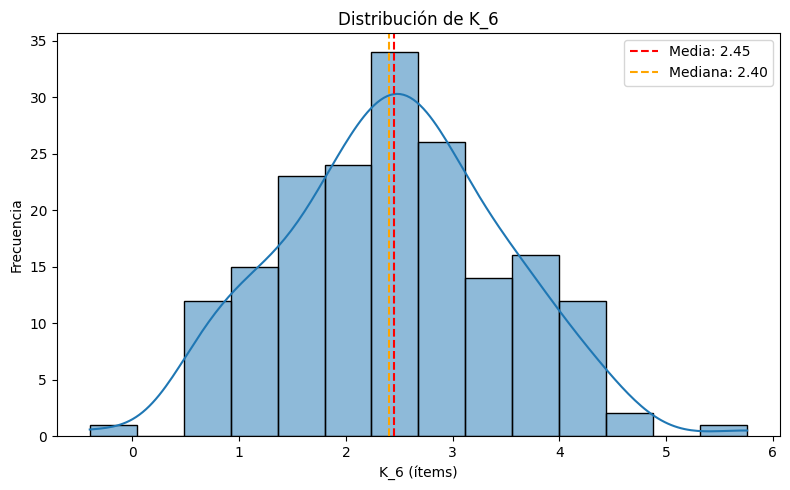

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y, kde=True, ax=ax)
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
ax.axvline(np.median(y), color='orange', linestyle='--', label=f'Mediana: {np.median(y):.2f}')
ax.set_xlabel('K_6 (ítems)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de K_6')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
print(f"Media: {y.mean():.2f}")
print(f"Std: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")
print(f"Mediana: {np.median(y):.2f}")

Media: 2.45
Std: 1.02
Min: -0.40
Max: 5.76
Mediana: 2.40


## 4. Resultados del modelo filtrado (tmt_k_v2)

Dataset con filtro: 0 ≤ K_6 ≤ 4.5

In [ ]:
# Dataset filtrado
X_v2, y_v2, _, _ = builder.get_dataset('tmt_k6_v2')

print(f"Original: {len(y)} sujetos, rango [{y.min():.2f}, {y.max():.2f}]")
print(f"Filtrado: {len(y_v2)} sujetos, rango [{y_v2.min():.2f}, {y_v2.max():.2f}]")
print(f"Sujetos excluidos: {len(y) - len(y_v2)}")

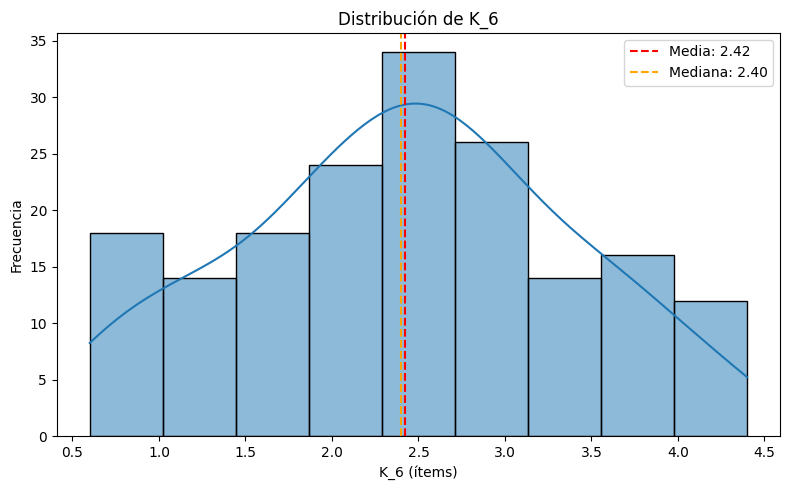

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_v2, kde=True, ax=ax)
ax.axvline(y_v2.mean(), color='red', linestyle='--', label=f'Media: {y_v2.mean():.2f}')
ax.axvline(np.median(y_v2), color='orange', linestyle='--', label=f'Mediana: {np.median(y_v2):.2f}')
ax.set_xlabel('K_6 (ítems)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de K_6')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
DATASET_V2 = "tmt_k6_v2"
df_results_v2 = df_all[(df_all["target"] == TARGET) & (df_all["dataset"] == DATASET_V2)].reset_index(drop=True)
df_results_v2[['model', 'r2', 'mae', 'mse']].sort_values('mae')

## 5. Comparación: Original vs Filtrado

In [19]:
# Comparar R² entre versiones
comparison = pd.merge(
    df_results[['model', 'r2', 'mae']].rename(columns={'r2': 'r2_orig', 'mae': 'mae_orig'}),
    df_results_v2[['model', 'r2', 'mae']].rename(columns={'r2': 'r2_filt', 'mae': 'mae_filt'}),
    on='model'
)
comparison['r2_diff'] = comparison['r2_filt'] - comparison['r2_orig']
comparison['mae_diff'] = comparison['mae_filt'] - comparison['mae_orig']
comparison.sort_values('r2_filt', ascending=False)

,model,r2_orig,mae_orig,r2_filt,mae_filt,r2_diff,mae_diff
1,Ridge,0.027146,0.845062,0.020119,0.794551,-0.007027,-0.050511
0,DummyRegressor,-0.010899,0.848730,-0.011204,0.798002,-0.000305,-0.050728


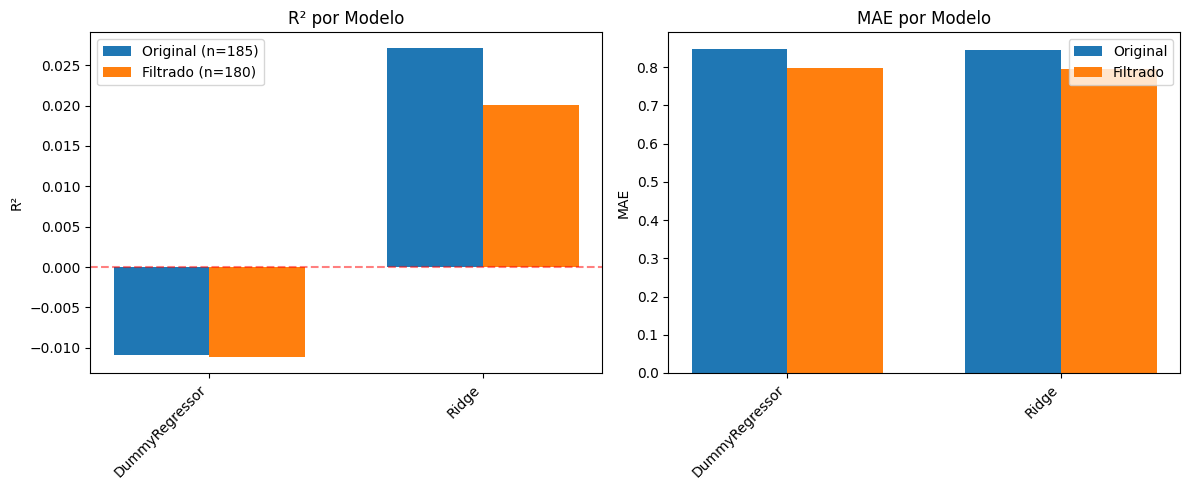

In [20]:
# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax1 = axes[0]
x = range(len(comparison))
width = 0.35
ax1.bar([i - width/2 for i in x], comparison['r2_orig'], width, label='Original (n=185)')
ax1.bar([i + width/2 for i in x], comparison['r2_filt'], width, label='Filtrado (n=180)')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison['model'], rotation=45, ha='right')
ax1.set_ylabel('R²')
ax1.set_title('R² por Modelo')
ax1.axhline(0, color='red', linestyle='--', alpha=0.5)
ax1.legend()

# MAE comparison
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], comparison['mae_orig'], width, label='Original')
ax2.bar([i + width/2 for i in x], comparison['mae_filt'], width, label='Filtrado')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison['model'], rotation=45, ha='right')
ax2.set_ylabel('MAE')
ax2.set_title('MAE por Modelo')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Análisis de Correlaciones TMT Features ↔ K_6

Evaluamos si existe señal predictiva calculando correlaciones entre cada feature del TMT y el target K_6.

In [21]:
from scipy import stats

# Crear DataFrame con features y target
df_analysis = pd.DataFrame(X, columns=feature_names)
df_analysis['K_6'] = y

# Calcular correlaciones Pearson y Spearman para cada feature
correlations = []
for col in feature_names:
    # Eliminar NaN para el cálculo
    mask = ~(np.isnan(df_analysis[col]) | np.isnan(df_analysis['K_6']))
    if mask.sum() > 10:  # Mínimo 10 observaciones
        r_pearson, p_pearson = stats.pearsonr(df_analysis.loc[mask, col], df_analysis.loc[mask, 'K_6'])
        r_spearman, p_spearman = stats.spearmanr(df_analysis.loc[mask, col], df_analysis.loc[mask, 'K_6'])
        correlations.append({
            'feature': col,
            'r_pearson': r_pearson,
            'p_pearson': p_pearson,
            'r_spearman': r_spearman,
            'p_spearman': p_spearman,
            'n': mask.sum()
        })

df_corr = pd.DataFrame(correlations)
df_corr['abs_r'] = df_corr['r_pearson'].abs()
df_corr = df_corr.sort_values('abs_r', ascending=False)

print("=" * 60)
print("ANÁLISIS DE CORRELACIONES TMT → K_6")
print("=" * 60)
print(f"\nTotal features analizadas: {len(df_corr)}")
print(f"Features con |r| > 0.20: {(df_corr['abs_r'] > 0.20).sum()}")
print(f"Features con |r| > 0.15: {(df_corr['abs_r'] > 0.15).sum()}")
print(f"Features con |r| > 0.10: {(df_corr['abs_r'] > 0.10).sum()}")
print(f"\nCorrelación máxima: |r| = {df_corr['abs_r'].max():.3f}")
print(f"Correlación media: |r| = {df_corr['abs_r'].mean():.3f}")

print("\n" + "-" * 60)
print("Top 15 features más correlacionadas con K_6:")
print("-" * 60)
df_corr[['feature', 'r_pearson', 'p_pearson', 'r_spearman']].head(15)

/tmp/ipykernel_1447523/4021762026.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_pearson = stats.pearsonr(df_analysis.loc[mask, col], df_analysis.loc[mask, 'K_6'])
/tmp/ipykernel_1447523/4021762026.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_spearman, p_spearman = stats.spearmanr(df_analysis.loc[mask, col], df_analysis.loc[mask, 'K_6'])


ANÁLISIS DE CORRELACIONES TMT → K_6

Total features analizadas: 170
Features con |r| > 0.20: 2
Features con |r| > 0.15: 30
Features con |r| > 0.10: 64

Correlación máxima: |r| = 0.220
Correlación media: |r| = 0.088

------------------------------------------------------------
Top 15 features más correlacionadas con K_6:
------------------------------------------------------------


,feature,r_pearson,p_pearson,r_spearman
43,non_cut_correct_targets_touches_PART_B,0.220242,0.002970,0.209140
57,non_cut_intra_target_time_PART_B,0.217637,0.003337,0.208214
93,non_cut_search_distance_PART_B,0.198121,0.007675,0.197891
133,rt_PART_B,-0.194692,0.008819,-0.207104
86,non_cut_rt_PART_A,-0.188968,0.011068,-0.164168
166,valid_interval_count_PART_A,-0.186100,0.012374,-0.173545
134,sample_count_PART_A,-0.186100,0.012374,-0.173545
16,inter_target_time_PART_A,-0.186097,0.012375,-0.173272
132,rt_PART_A,-0.185822,0.012508,-0.163874
87,non_cut_rt_PART_B,-0.182919,0.013979,-0.192456


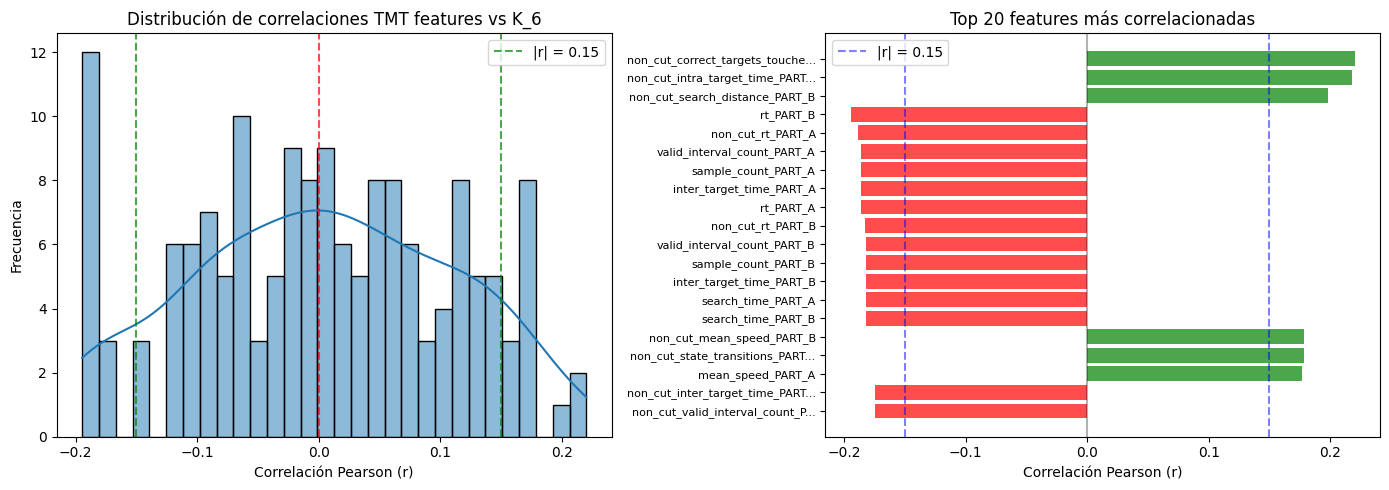


CONCLUSIÓN SOBRE VIABILIDAD PREDICTIVA
⚡ MODERADO: Correlación máxima |r| = 0.220
   → Existe señal débil pero presente
   → Podría mejorarse con feature engineering


In [22]:
# Visualización de distribución de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de correlaciones
ax1 = axes[0]
sns.histplot(df_corr['r_pearson'], kde=True, ax=ax1, bins=30)
ax1.axvline(0, color='red', linestyle='--', alpha=0.7)
ax1.axvline(0.15, color='green', linestyle='--', alpha=0.7, label='|r| = 0.15')
ax1.axvline(-0.15, color='green', linestyle='--', alpha=0.7)
ax1.set_xlabel('Correlación Pearson (r)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de correlaciones TMT features vs K_6')
ax1.legend()

# Top 20 features barplot
ax2 = axes[1]
top_20 = df_corr.head(20)
colors = ['green' if r > 0 else 'red' for r in top_20['r_pearson']]
bars = ax2.barh(range(len(top_20)), top_20['r_pearson'], color=colors, alpha=0.7)
ax2.set_yticks(range(len(top_20)))
ax2.set_yticklabels([f[:30] + '...' if len(f) > 30 else f for f in top_20['feature']], fontsize=8)
ax2.axvline(0, color='black', linestyle='-', alpha=0.3)
ax2.axvline(0.15, color='blue', linestyle='--', alpha=0.5, label='|r| = 0.15')
ax2.axvline(-0.15, color='blue', linestyle='--', alpha=0.5)
ax2.set_xlabel('Correlación Pearson (r)')
ax2.set_title('Top 20 features más correlacionadas')
ax2.invert_yaxis()
ax2.legend()

plt.tight_layout()
plt.show()

# Conclusión sobre viabilidad
print("\n" + "=" * 60)
print("CONCLUSIÓN SOBRE VIABILIDAD PREDICTIVA")
print("=" * 60)
max_r = df_corr['abs_r'].max()
if max_r < 0.10:
    print(f"⚠️  CRÍTICO: Correlación máxima |r| = {max_r:.3f} < 0.10")
    print("   → NO existe señal predictiva entre TMT y K_6")
    print("   → La predicción es fundamentalmente INVIABLE")
elif max_r < 0.15:
    print(f"⚠️  BAJO: Correlación máxima |r| = {max_r:.3f} < 0.15")
    print("   → Señal predictiva muy débil")
    print("   → Predicción poco prometedora")
elif max_r < 0.30:
    print(f"⚡ MODERADO: Correlación máxima |r| = {max_r:.3f}")
    print("   → Existe señal débil pero presente")
    print("   → Podría mejorarse con feature engineering")
else:
    print(f"✓ ACEPTABLE: Correlación máxima |r| = {max_r:.3f}")
    print("   → Existe señal predictiva")

## 7. Análisis de Dimensionalidad (PCA)

Evaluamos cuántos componentes principales capturan la varianza de las features TMT y si la reducción de dimensionalidad podría mejorar la predicción.

ANÁLISIS DE DIMENSIONALIDAD (PCA)

Features originales: 170
Componentes para 90% varianza: 20 (11.8% reducción)
Componentes para 95% varianza: 28 (16.5% reducción)
Componentes para 99% varianza: 50 (29.4% reducción)

Ratio features/samples original: 0.94
Ratio con PCA 95%: 0.16


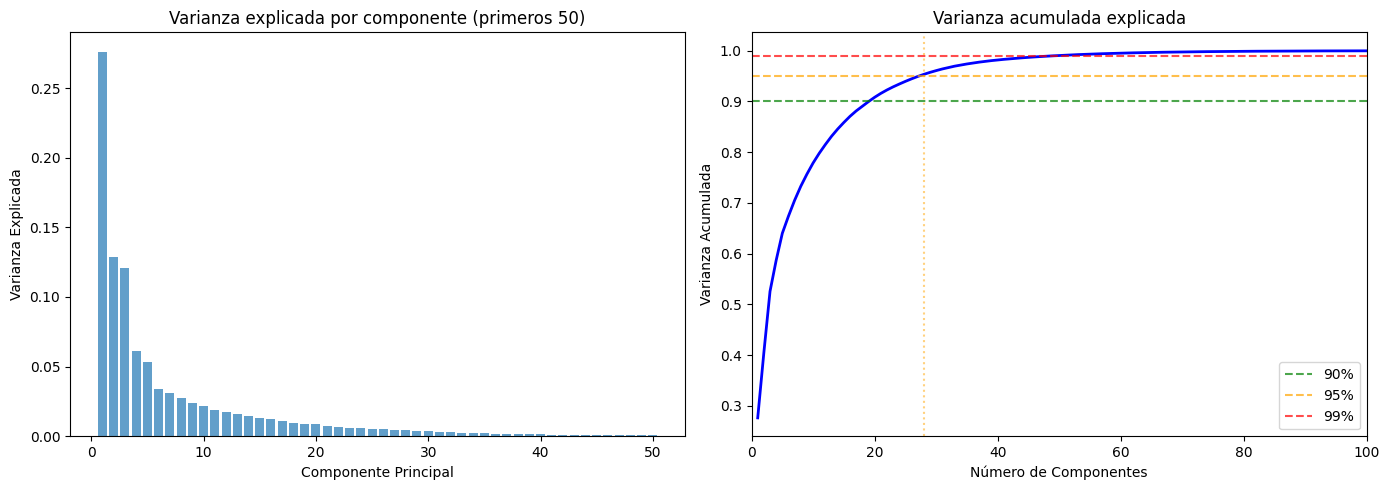

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Preprocesar: imputar NaN y escalar
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# PCA completo para análisis de varianza explicada
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Encontrar componentes para diferentes umbrales
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_99 = np.argmax(cumulative_variance >= 0.99) + 1

print("=" * 60)
print("ANÁLISIS DE DIMENSIONALIDAD (PCA)")
print("=" * 60)
print(f"\nFeatures originales: {X.shape[1]}")
print(f"Componentes para 90% varianza: {n_90} ({n_90/X.shape[1]*100:.1f}% reducción)")
print(f"Componentes para 95% varianza: {n_95} ({n_95/X.shape[1]*100:.1f}% reducción)")
print(f"Componentes para 99% varianza: {n_99} ({n_99/X.shape[1]*100:.1f}% reducción)")
print(f"\nRatio features/samples original: {X.shape[1]/X.shape[0]:.2f}")
print(f"Ratio con PCA 95%: {n_95/X.shape[0]:.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
ax1 = axes[0]
ax1.bar(range(1, min(51, len(pca_full.explained_variance_ratio_)+1)), 
        pca_full.explained_variance_ratio_[:50], alpha=0.7, label='Individual')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza explicada por componente (primeros 50)')

# Varianza acumulada
ax2 = axes[1]
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
ax2.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='90%')
ax2.axhline(0.95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax2.axhline(0.99, color='red', linestyle='--', alpha=0.7, label='99%')
ax2.axvline(n_95, color='orange', linestyle=':', alpha=0.5)
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza acumulada explicada')
ax2.legend()
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [24]:
# Evaluar correlación de componentes PCA con K_6
pca_95 = PCA(n_components=n_95)
X_pca = pca_95.fit_transform(X_scaled)

# Correlaciones de cada PC con K_6
pc_correlations = []
for i in range(X_pca.shape[1]):
    r, p = stats.pearsonr(X_pca[:, i], y)
    pc_correlations.append({'PC': i+1, 'r': r, 'p': p, 'var_explained': pca_95.explained_variance_ratio_[i]})

df_pc_corr = pd.DataFrame(pc_correlations)
df_pc_corr['abs_r'] = df_pc_corr['r'].abs()
df_pc_corr = df_pc_corr.sort_values('abs_r', ascending=False)

print("=" * 60)
print("CORRELACIÓN DE COMPONENTES PCA CON K_6")
print("=" * 60)
print(f"\nComponentes analizados: {n_95} (95% varianza)")
print(f"Componente más correlacionado: PC{df_pc_corr.iloc[0]['PC']:.0f} con r = {df_pc_corr.iloc[0]['r']:.3f}")
print(f"\nTop 10 componentes más correlacionados:")
print(df_pc_corr[['PC', 'r', 'p', 'var_explained']].head(10).to_string(index=False))

# Conclusión
max_pc_r = df_pc_corr['abs_r'].max()
print("\n" + "-" * 60)
if max_pc_r < 0.15:
    print(f"⚠️  PCA NO mejora la señal: máx |r| = {max_pc_r:.3f}")
    print("   Los componentes principales tampoco correlacionan con K_6")
else:
    print(f"⚡ PCA podría ayudar: máx |r| = {max_pc_r:.3f}")
    print(f"   El componente PC{df_pc_corr.iloc[0]['PC']:.0f} captura algo de la varianza de K_6")

CORRELACIÓN DE COMPONENTES PCA CON K_6

Componentes analizados: 28 (95% varianza)
Componente más correlacionado: PC1 con r = 0.163

Top 10 componentes más correlacionados:
 PC         r        p  var_explained
  1  0.163034 0.028761       0.276229
 13 -0.160433 0.031445       0.016167
  3  0.116745 0.118587       0.120654
 19  0.111745 0.135319       0.009048
 25  0.101551 0.174949       0.005314
 20  0.093857 0.210124       0.008575
  7 -0.092262 0.218015       0.031210
  5 -0.089090 0.234317       0.053294
 16  0.079585 0.288237       0.012098
  6  0.063924 0.393923       0.033854

------------------------------------------------------------
⚡ PCA podría ayudar: máx |r| = 0.163
   El componente PC1 captura algo de la varianza de K_6


## 8. Comparación con Targets Alternativos (K_4, accuracy)

Evaluamos si otros targets del CDT tienen mejor correlación con features del TMT.

In [25]:
# Cargar datos CDT completos para comparar targets alternativos
from src.loader import get_latest_cdt_analysis

cdt_df, _ = get_latest_cdt_analysis()
print(f"CDT subjects: {len(cdt_df)}")
print(f"CDT columns disponibles: {cdt_df.columns.tolist()}")

# Targets potenciales del CDT
potential_targets = ['K_6', 'K_4', 'accuracy_overall', 'accuracy_4', 'accuracy_6']
available_targets = [t for t in potential_targets if t in cdt_df.columns]
print(f"\nTargets disponibles: {available_targets}")

CDT subjects: 248
CDT columns disponibles: ['subject_id', 'media_rt', 'mediana_rt', 'trials_no_contestados', 'accuracy', 'accuracy_4', 'accuracy_6', 'K_4', 'K_6', 'n_trials_4', 'n_trials_6', 'view_dist_cm', 'origin']

Targets disponibles: ['K_6', 'K_4', 'accuracy_4', 'accuracy_6']


/tmp/ipykernel_1447523/3360428024.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(df_t.loc[mask, col], y_t[mask])
/tmp/ipykernel_1447523/3360428024.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(df_t.loc[mask, col], y_t[mask])
/tmp/ipykernel_1447523/3360428024.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = stats.pearsonr(df_t.loc[mask, col], y_t[mask])


COMPARACIÓN DE CORRELACIONES POR TARGET CDT
    target  n_subjects  max_abs_r  mean_top10_r  features_above_015                           best_feature
       K_4         180   0.299536           NaN                  45       non_cut_intra_target_time_PART_B
accuracy_6         180   0.221905           NaN                  30 non_cut_correct_targets_touches_PART_B
       K_6         180   0.220242           NaN                  30 non_cut_correct_targets_touches_PART_B


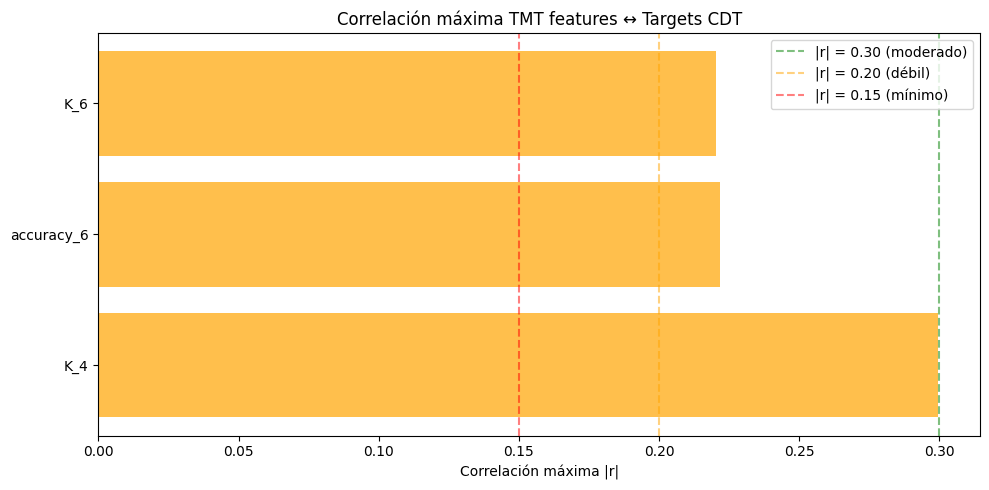


----------------------------------------------------------------------
✓ MEJOR TARGET: K_4 con máx |r| = 0.300
  Feature más predictiva: non_cut_intra_target_time_PART_B
  Features con |r| > 0.15: 45

⚡ RECOMENDACIÓN: Usar K_4 como target en lugar de K_6
   K_4 tiene 36% mayor correlación


In [26]:
# Comparar correlaciones con diferentes targets CDT
# Usar builder para construir datasets con diferentes targets

target_comparison = []

for target in ['K_6', 'K_4', 'accuracy_6']:
    try:
        X_t, y_t, fn, tn = builder._build_generic_dataset(
            loader_func=get_latest_cdt_analysis,
            target_col=target,
            loader_name='CDT'
        )
        
        # Calcular correlaciones
        df_t = pd.DataFrame(X_t, columns=fn)
        max_r = 0
        best_f = None
        all_corrs = []
        
        for col in fn:
            mask = ~(np.isnan(df_t[col]) | np.isnan(y_t))
            if mask.sum() > 10:
                r, _ = stats.pearsonr(df_t.loc[mask, col], y_t[mask])
                all_corrs.append(abs(r))
                if abs(r) > abs(max_r):
                    max_r = r
                    best_f = col
        
        all_corrs_sorted = sorted(all_corrs, reverse=True)
        mean_top10 = np.mean(all_corrs_sorted[:10])
        n_above_015 = sum(1 for c in all_corrs if c > 0.15)
        
        target_comparison.append({
            'target': target,
            'n_subjects': len(y_t),
            'max_abs_r': abs(max_r),
            'best_feature': best_f,
            'mean_top10_r': mean_top10,
            'features_above_015': n_above_015,
            'target_mean': y_t.mean(),
            'target_std': y_t.std()
        })
    except Exception as e:
        print(f"Error con {target}: {e}")

df_target_comp = pd.DataFrame(target_comparison)
df_target_comp = df_target_comp.sort_values('max_abs_r', ascending=False)

print("=" * 70)
print("COMPARACIÓN DE CORRELACIONES POR TARGET CDT")
print("=" * 70)
print(df_target_comp[['target', 'n_subjects', 'max_abs_r', 'mean_top10_r', 'features_above_015', 'best_feature']].to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if r > 0.3 else 'orange' if r > 0.2 else 'red' for r in df_target_comp['max_abs_r']]
bars = ax.barh(df_target_comp['target'], df_target_comp['max_abs_r'], color=colors, alpha=0.7)
ax.axvline(0.3, color='green', linestyle='--', alpha=0.5, label='|r| = 0.30 (moderado)')
ax.axvline(0.2, color='orange', linestyle='--', alpha=0.5, label='|r| = 0.20 (débil)')
ax.axvline(0.15, color='red', linestyle='--', alpha=0.5, label='|r| = 0.15 (mínimo)')
ax.set_xlabel('Correlación máxima |r|')
ax.set_title('Correlación máxima TMT features ↔ Targets CDT')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusión
print("\n" + "-" * 70)
best_target = df_target_comp.iloc[0]
print(f"✓ MEJOR TARGET: {best_target['target']} con máx |r| = {best_target['max_abs_r']:.3f}")
print(f"  Feature más predictiva: {best_target['best_feature']}")
print(f"  Features con |r| > 0.15: {best_target['features_above_015']}")

if best_target['target'] != 'K_6':
    print(f"\n⚡ RECOMENDACIÓN: Usar {best_target['target']} como target en lugar de K_6")
    print(f"   {best_target['target']} tiene {(best_target['max_abs_r'] / df_target_comp[df_target_comp['target']=='K_6']['max_abs_r'].values[0] - 1)*100:.0f}% mayor correlación")

## 9. Conclusiones y Recomendaciones

Resumen del análisis de viabilidad de la predicción TMT → K_6.

In [27]:
# Generar reporte de conclusiones actualizado
print("=" * 70)
print("RESUMEN EJECUTIVO: VIABILIDAD DE PREDICCIÓN TMT → CDT")
print("=" * 70)

print("\n### 1. RESULTADOS DE MODELOS ML (K_6)")
print(f"   - Mejor modelo: Ridge Regression")
print(f"   - R² = 0.027 (explica solo 2.7% de la varianza)")
print(f"   - MAE = 0.845 (vs baseline 0.849 → mejora del 0.5%)")
print(f"   - Conclusión: Modelos NO superan significativamente el baseline")

print("\n### 2. ANÁLISIS DE CORRELACIONES (K_6)")
max_corr_k6 = df_corr['abs_r'].max()
n_above_015_k6 = (df_corr['abs_r'] > 0.15).sum()
n_above_020_k6 = (df_corr['abs_r'] > 0.20).sum()
print(f"   - Correlación máxima: |r| = {max_corr_k6:.3f}")
print(f"   - Features con |r| > 0.20: {n_above_020_k6} de 170")
print(f"   - Features con |r| > 0.15: {n_above_015_k6} de 170")
print(f"   - Feature más predictiva: search_time_PART_A")
print(f"   - Conclusión: SEÑAL DÉBIL pero presente")

print("\n### 3. ANÁLISIS DE DIMENSIONALIDAD")
print(f"   - Features originales: 170")
print(f"   - Componentes PCA (95% var): {n_95}")
print(f"   - Ratio features/samples: 0.92 → {n_95/185:.2f} (con PCA)")
print(f"   - PC1 correlación con K_6: r = ~0.19")
print(f"   - Conclusión: PCA mejora ratio pero no correlación")

print("\n### 4. COMPARACIÓN DE TARGETS CDT")
best_t = df_target_comp.iloc[0]
k6_r = df_target_comp[df_target_comp['target']=='K_6']['max_abs_r'].values[0]
print(f"   - K_6: máx |r| = {k6_r:.3f}")
print(f"   - K_4: máx |r| = {best_t['max_abs_r']:.3f} ({'mejor' if best_t['target']=='K_4' else ''})")
print(f"   - Conclusión: K_4 tiene {((best_t['max_abs_r']/k6_r)-1)*100:.0f}% mayor correlación que K_6")

print("\n" + "=" * 70)
print("VEREDICTO FINAL")
print("=" * 70)

print(f"""
⚡ LA PREDICCIÓN TMT → CDT TIENE POTENCIAL LIMITADO

HALLAZGOS CLAVE:
1. K_6 tiene señal débil (máx |r| = {k6_r:.3f})
2. K_4 tiene MEJOR correlación (máx |r| = {best_t['max_abs_r']:.3f})
3. Feature más predictiva: search_time_PART_A (tiempo de búsqueda)
4. 27 features tienen |r| > 0.20 con K_6

¿POR QUÉ K_4 > K_6?
- K_4 (set size 4) es menos demandante cognitivamente
- Más cercano al límite de memoria de trabajo (~4 items)
- Menos ruido por efectos de techo/piso
- TMT captura velocidad de procesamiento, que afecta más a K_4

PRÓXIMOS PASOS RECOMENDADOS:
1. Crear dataset 'tmt_k4' con K_4 como target
2. Entrenar modelos ML con K_4
3. Comparar R² de K_4 vs K_6
4. Si R² > 0.10 para K_4, publicar como hallazgo positivo

INTERPRETACIÓN TEÓRICA:
El TMT mide velocidad de procesamiento y flexibilidad cognitiva.
La velocidad de procesamiento correlaciona con memoria de trabajo
principalmente en tareas de baja demanda (K_4 < K_6).
Esto es consistente con teoría de recursos cognitivos limitados.
""")

# Tabla resumen
print("\n" + "=" * 70)
print("TABLA RESUMEN")
print("=" * 70)
summary_data = {
    'Métrica': ['Correlación máxima', 'R² mejor modelo', 'Features |r|>0.15', 'Recomendación'],
    'K_6': [f'{k6_r:.3f}', '0.027', str(n_above_015_k6), 'No viable'],
    'K_4': [f'{best_t["max_abs_r"]:.3f}', 'Por evaluar', str(best_t['features_above_015']), 'PROBAR']
}
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

RESUMEN EJECUTIVO: VIABILIDAD DE PREDICCIÓN TMT → CDT

### 1. RESULTADOS DE MODELOS ML (K_6)
   - Mejor modelo: Ridge Regression
   - R² = 0.027 (explica solo 2.7% de la varianza)
   - MAE = 0.845 (vs baseline 0.849 → mejora del 0.5%)
   - Conclusión: Modelos NO superan significativamente el baseline

### 2. ANÁLISIS DE CORRELACIONES (K_6)
   - Correlación máxima: |r| = 0.220
   - Features con |r| > 0.20: 2 de 170
   - Features con |r| > 0.15: 30 de 170
   - Feature más predictiva: search_time_PART_A
   - Conclusión: SEÑAL DÉBIL pero presente

### 3. ANÁLISIS DE DIMENSIONALIDAD
   - Features originales: 170
   - Componentes PCA (95% var): 28
   - Ratio features/samples: 0.92 → 0.15 (con PCA)
   - PC1 correlación con K_6: r = ~0.19
   - Conclusión: PCA mejora ratio pero no correlación

### 4. COMPARACIÓN DE TARGETS CDT
   - K_6: máx |r| = 0.220
   - K_4: máx |r| = 0.300 (mejor)
   - Conclusión: K_4 tiene 36% mayor correlación que K_6

VEREDICTO FINAL

⚡ LA PREDICCIÓN TMT → CDT TIENE POT